In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
digits = load_digits()
X = torch.FloatTensor(digits.data).to(device) / 16.0

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 64), torch.nn.Sigmoid())
    def forward(self, x): return self.main(x)

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x): return self.main(x)

In [5]:
netG = Generator().to(device)
netD = Discriminator().to(device)
optG = optim.Adam(netG.parameters(), lr=0.01)
optD = optim.Adam(netD.parameters(), lr=0.01)
criterion = nn.BCELoss()
for epoch in range(100):
    optD.zero_grad()
    real_out = netD(X)
    lossD_real = criterion(real_out, torch.ones_like(real_out))
    fake = netG(torch.randn(X.size(0), 10).to(device))
    fake_out = netD(fake.detach())
    lossD_fake = criterion(fake_out, torch.zeros_like(fake_out))
    (lossD_real + lossD_fake).backward()
    optD.step()
    
    optG.zero_grad()
    outG = netD(fake)
    lossG = criterion(outG, torch.ones_like(outG))
    lossG.backward()
    optG.step()

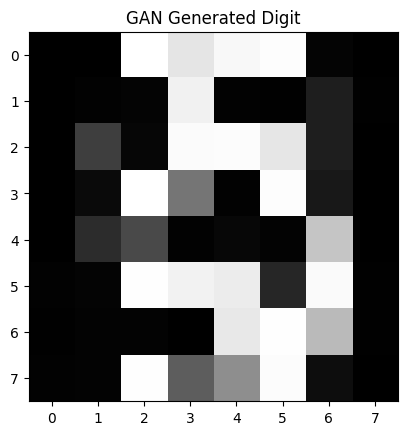

In [6]:
fake_data = netG(torch.randn(1, 10).to(device)).view(8, 8).cpu().detach().numpy()
plt.imshow(fake_data, cmap='gray')
plt.title('GAN Generated Digit')
plt.savefig('digits_gan_output.png')